# Bayesian Change Point Analysis of Brent Oil Prices

## Week 10 Challenge — Task 2

**Author:** E. Frida N.

This notebook applies Bayesian change point detection to identify a structural shift in historical Brent crude oil prices. The model estimates the most probable change-point date and compares the average price before and after the detected shift.

In [1]:
import pymc as pm
import arviz as az

print("PyMC version:", pm.__version__)
print("ArviZ version:", az.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC version: 6.1.0
ArviZ version: 1.2.0


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (15, 6)

RANDOM_SEED = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load Brent oil price data
data_path = Path("../data/raw/BrentOilPrices.csv")

df = pd.read_csv(data_path)

# Convert date and price columns
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%b-%y",
    errors="coerce"
)

df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

# Clean and sort
df = (
    df.dropna(subset=["Date", "Price"])
      .drop_duplicates(subset=["Date"])
      .sort_values("Date")
      .reset_index(drop=True)
)

print("Dataset shape:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())

df.head()

Dataset shape: (8360, 2)
Date range: 1987-05-20 00:00:00 to 2020-04-21 00:00:00


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


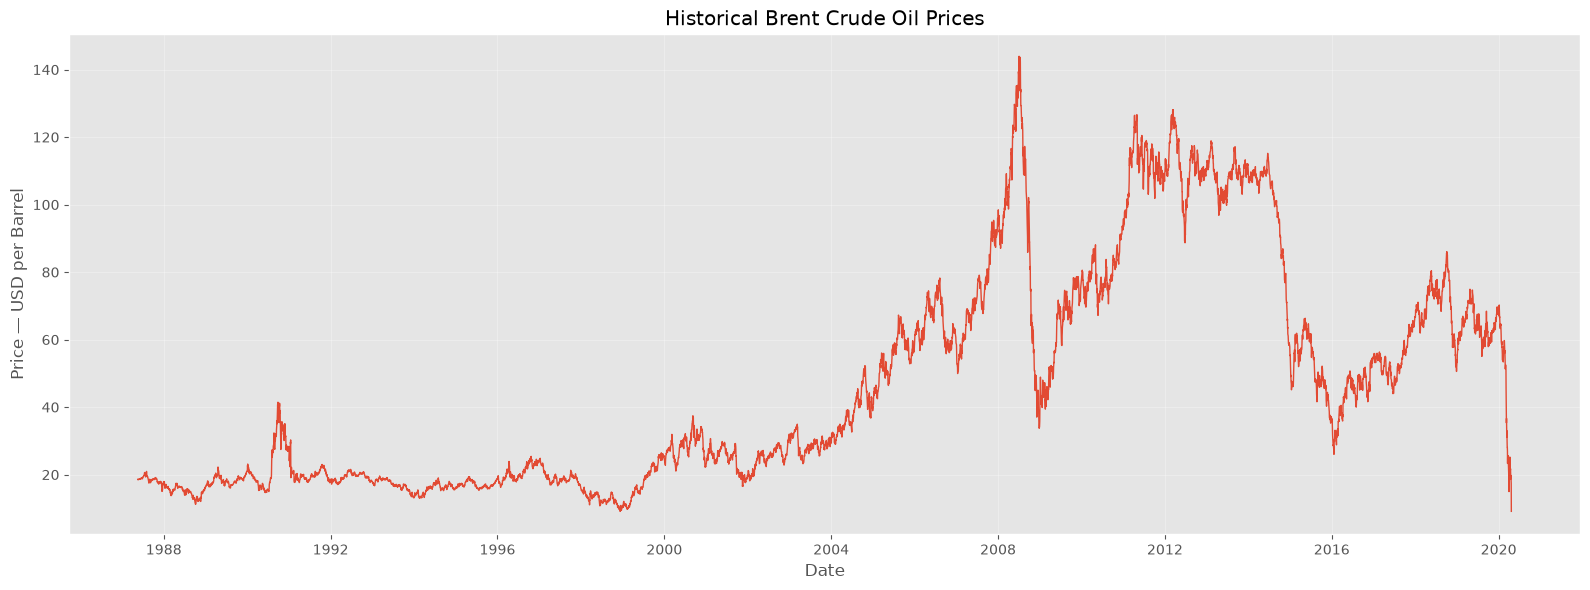

In [4]:
plt.figure(figsize=(16, 6))

plt.plot(
    df["Date"],
    df["Price"],
    linewidth=1
)

plt.title("Historical Brent Crude Oil Prices")
plt.xlabel("Date")
plt.ylabel("Price — USD per Barrel")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Bayesian Model Preparation

The daily Brent oil dataset contains thousands of observations. To reduce short-term noise and make Bayesian sampling computationally manageable, the series is aggregated to monthly average prices.

This preserves the major long-term structural movements while significantly reducing model runtime. The detected monthly change point will later be compared with the original daily series and the geopolitical event dataset.

In [5]:
# Aggregate daily observations to monthly average prices
monthly_df = (
    df.set_index("Date")["Price"]
      .resample("MS")
      .mean()
      .dropna()
      .reset_index()
)

monthly_df.columns = ["Date", "Price"]

print("Monthly observations:", len(monthly_df))
print("Date range:", monthly_df["Date"].min(), "to", monthly_df["Date"].max())

monthly_df.head()

Monthly observations: 396
Date range: 1987-05-01 00:00:00 to 2020-04-01 00:00:00


,Date,Price
0,1987-05-01,18.580000
1,1987-06-01,18.860476
2,1987-07-01,19.856522
3,1987-08-01,18.979524
4,1987-09-01,18.313182


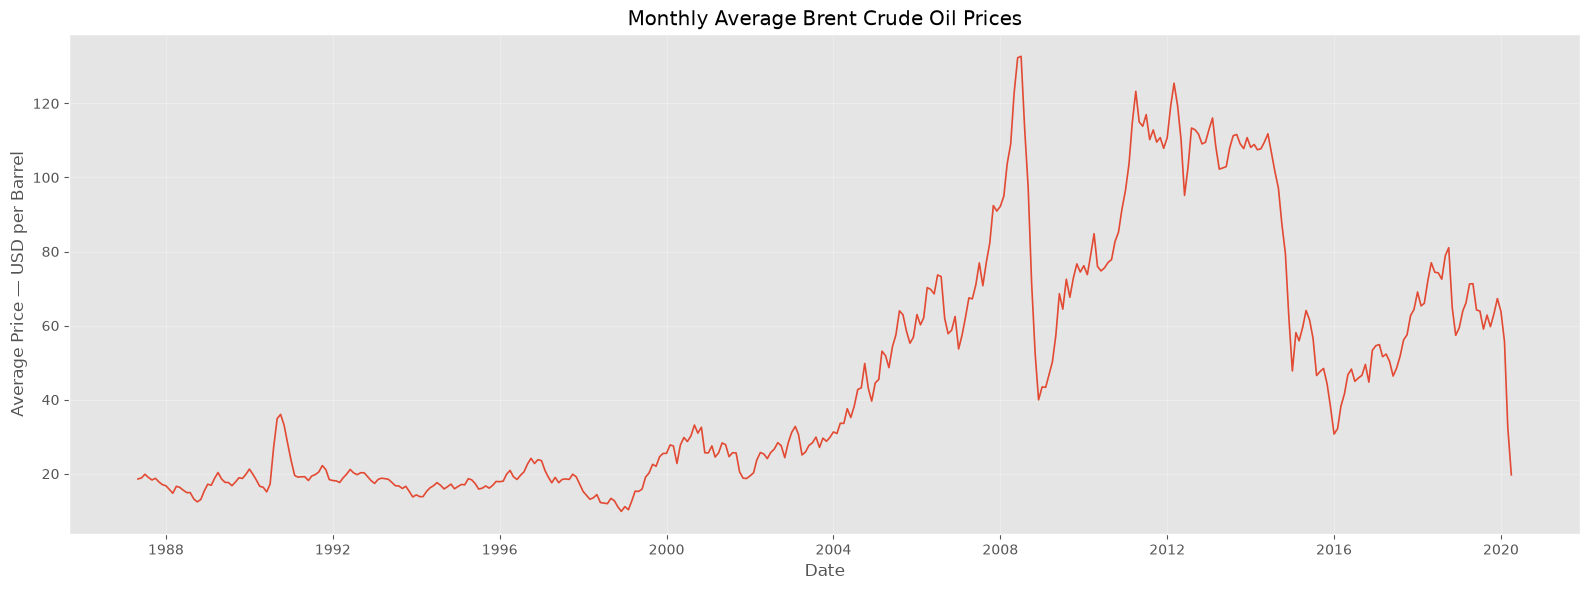

In [6]:
plt.figure(figsize=(16, 6))

plt.plot(
    monthly_df["Date"],
    monthly_df["Price"],
    linewidth=1.2
)

plt.title("Monthly Average Brent Crude Oil Prices")
plt.xlabel("Date")
plt.ylabel("Average Price — USD per Barrel")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Convert the series to NumPy arrays for PyMC
prices = monthly_df["Price"].values.astype("float64")
time_index = np.arange(len(monthly_df))

print("Number of observations:", len(prices))
print("Overall mean price:", round(prices.mean(), 2))
print("Overall standard deviation:", round(prices.std(), 2))

Number of observations: 396
Overall mean price: 46.49
Overall standard deviation: 32.54


## Bayesian Single Change Point Model

A discrete uniform prior is assigned to the unknown switch point, denoted by \(\tau\). This gives every monthly observation an equal prior probability of representing the structural break.

Two separate mean parameters are estimated:

- \(\mu_{\text{before}}\): expected Brent price before the change point;
- \(\mu_{\text{after}}\): expected Brent price after the change point.

The `pm.math.switch` function selects the appropriate mean for every observation depending on whether it occurs before or after \(\tau\).

In [8]:
with pm.Model() as change_point_model:

    # Discrete prior for the unknown change-point position
    tau = pm.DiscreteUniform(
        "tau",
        lower=1,
        upper=len(prices) - 2
    )

    # Weakly informative priors for the before and after means
    mu_before = pm.Normal(
        "mu_before",
        mu=prices.mean(),
        sigma=prices.std() * 2
    )

    mu_after = pm.Normal(
        "mu_after",
        mu=prices.mean(),
        sigma=prices.std() * 2
    )

    # Positive prior for residual variation
    sigma = pm.HalfNormal(
        "sigma",
        sigma=prices.std()
    )

    # Select the correct mean before and after tau
    expected_mean = pm.math.switch(
        time_index < tau,
        mu_before,
        mu_after
    )

    # Likelihood
    observed_prices = pm.Normal(
        "observed_prices",
        mu=expected_mean,
        sigma=sigma,
        observed=prices
    )

print("Bayesian change point model created successfully.")

Bayesian change point model created successfully.


In [9]:
with change_point_model:

    step_continuous = pm.NUTS(
        vars=[mu_before, mu_after, sigma],
        target_accept=0.90
    )

    step_discrete = pm.Metropolis(
        vars=[tau]
    )

    trace = pm.sample(
        draws=1500,
        tune=1000,
        chains=2,
        cores=1,
        step=[step_continuous, step_discrete],
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
        progressbar=True
    )

Sequential sampling (2 chains in 1 job)
CompoundStep
>NUTS: [mu_before, mu_after, sigma]
>Metropolis: [tau]


Output()

Sampling 2 chains for 1_000 tune and 1_500 draw iterations (2_000 + 3_000 draws total) took 42 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [10]:
summary = az.summary(
    trace,
    var_names=["tau", "mu_before", "mu_after", "sigma"],
    round_to=3
)

summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,214.229,1.895,212.000,217.000,473.232,545.701,1.003,0.090,0.075
mu_before,21.465,1.221,19.529,23.379,2329.528,2352.792,1.002,0.025,0.018
mu_after,75.993,1.318,73.855,78.133,2644.300,2270.847,1.001,0.026,0.018
sigma,17.977,0.648,16.993,19.075,2533.244,2067.203,1.000,0.013,0.009


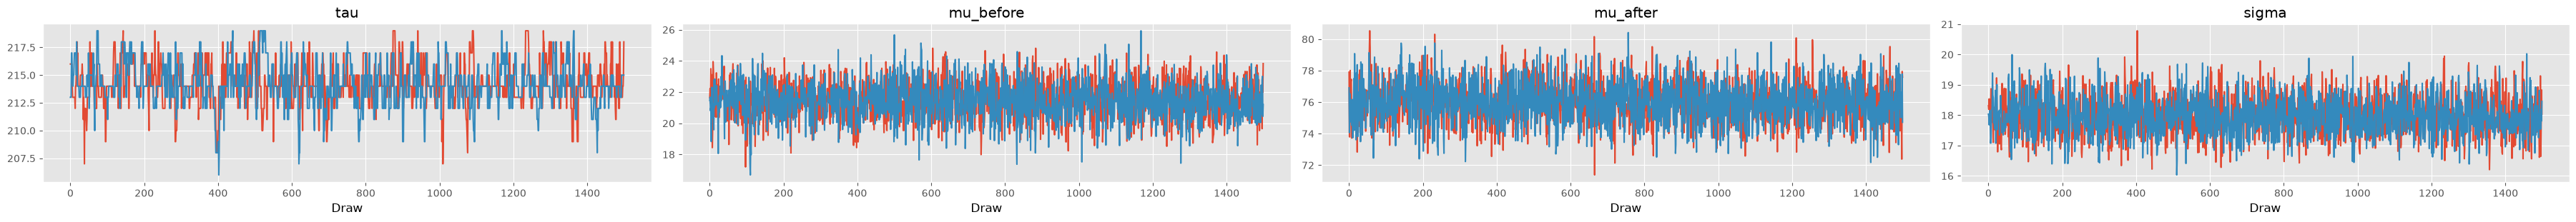

In [11]:
az.plot_trace(
    trace,
    var_names=["tau", "mu_before", "mu_after", "sigma"]
)

plt.tight_layout()
plt.show()

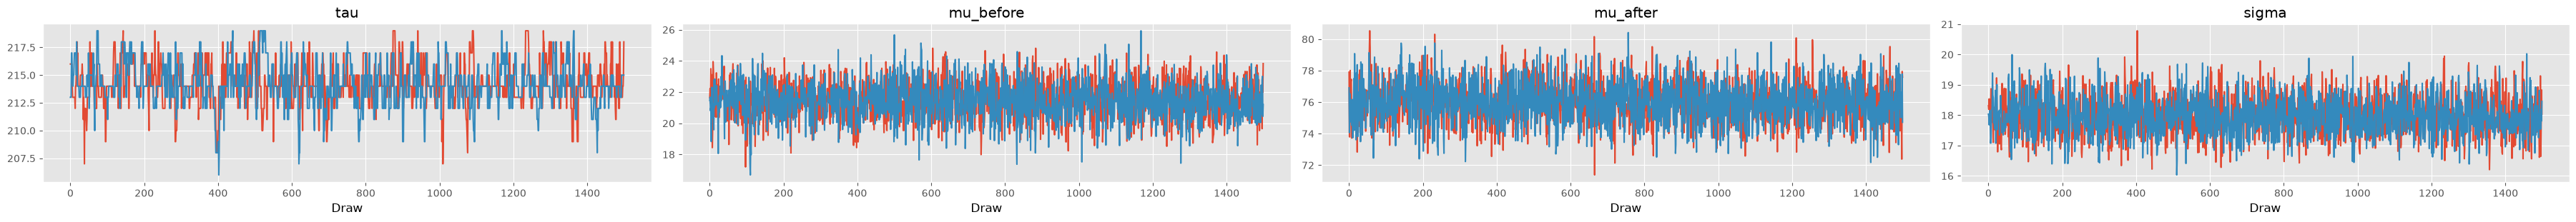

In [12]:
az.plot_trace(
    trace,
    var_names=["tau", "mu_before", "mu_after", "sigma"]
)

plt.tight_layout()
plt.show()

In [13]:
# Extract posterior samples
tau_samples = trace.posterior["tau"].values.flatten()

# Most probable change-point index
tau_mode = int(pd.Series(tau_samples).mode().iloc[0])

# Posterior median for additional robustness
tau_median = int(np.median(tau_samples))

change_date_mode = monthly_df.loc[tau_mode, "Date"]
change_date_median = monthly_df.loc[tau_median, "Date"]

print("Most probable change-point index:", tau_mode)
print("Most probable change-point date:", change_date_mode.strftime("%Y-%m-%d"))

print("\nPosterior median index:", tau_median)
print("Posterior median date:", change_date_median.strftime("%Y-%m-%d"))

Most probable change-point index: 214
Most probable change-point date: 2005-03-01

Posterior median index: 214
Posterior median date: 2005-03-01


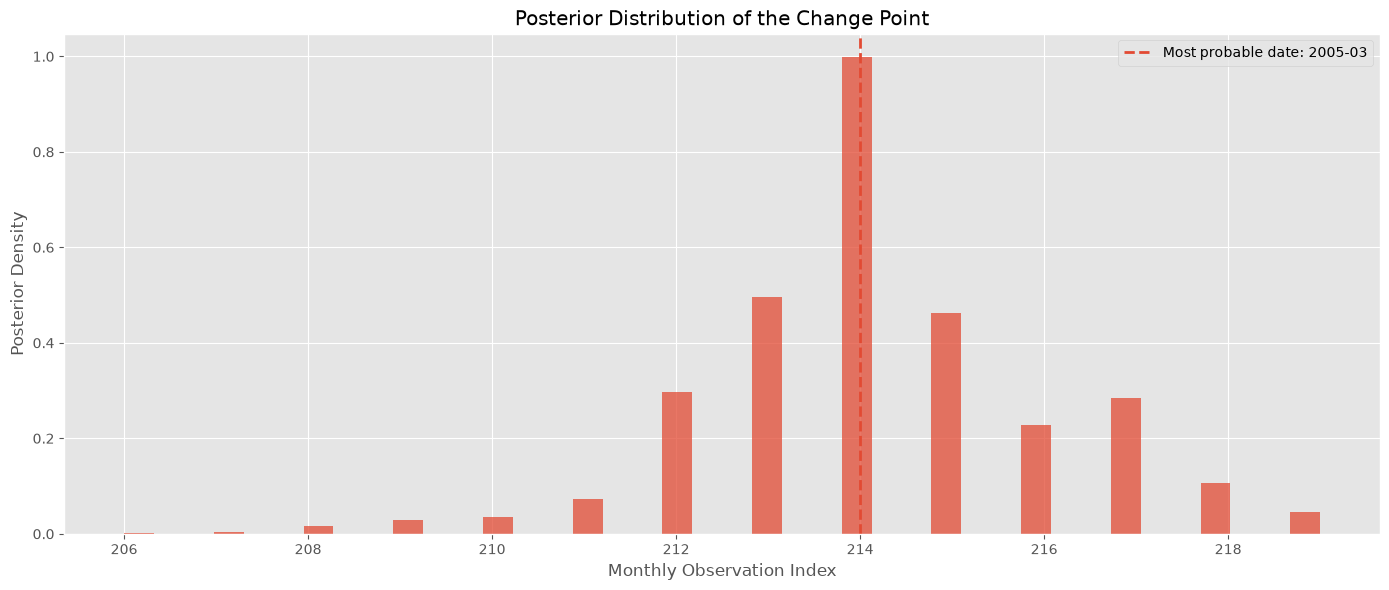

In [14]:
plt.figure(figsize=(14, 6))

plt.hist(
    tau_samples,
    bins=40,
    density=True,
    alpha=0.75
)

plt.axvline(
    tau_mode,
    linestyle="--",
    linewidth=2,
    label=f"Most probable date: {change_date_mode.strftime('%Y-%m')}"
)

plt.title("Posterior Distribution of the Change Point")
plt.xlabel("Monthly Observation Index")
plt.ylabel("Posterior Density")
plt.legend()
plt.tight_layout()
plt.show()

### Change Point Interpretation

The posterior distribution of \(\tau\) represents the probability that each monthly observation marks the structural break. A concentrated peak indicates strong model confidence in the estimated change-point period, while a wider distribution would suggest greater uncertainty.

In [15]:
mu_before_samples = trace.posterior["mu_before"].values.flatten()
mu_after_samples = trace.posterior["mu_after"].values.flatten()

mu_before_mean = mu_before_samples.mean()
mu_after_mean = mu_after_samples.mean()

absolute_change = mu_after_mean - mu_before_mean
percentage_change = (absolute_change / mu_before_mean) * 100

print(f"Estimated average price before change: ${mu_before_mean:.2f}")
print(f"Estimated average price after change:  ${mu_after_mean:.2f}")
print(f"Absolute change:                     ${absolute_change:.2f}")
print(f"Percentage change:                    {percentage_change:.2f}%")

Estimated average price before change: $21.46
Estimated average price after change:  $75.99
Absolute change:                     $54.53
Percentage change:                    254.04%


In [16]:
before_interval = az.hdi(mu_before_samples, hdi_prob=0.95)
after_interval = az.hdi(mu_after_samples, hdi_prob=0.95)

print(
    f"95% credible interval before change: "
    f"${before_interval[0]:.2f} to ${before_interval[1]:.2f}"
)

print(
    f"95% credible interval after change: "
    f"${after_interval[0]:.2f} to ${after_interval[1]:.2f}"
)

TypeError: hdi got an unexpected keyword argument: 'hdi_prob'

In [17]:
# 95% credible intervals using posterior quantiles

before_interval = np.quantile(
    mu_before_samples,
    [0.025, 0.975]
)

after_interval = np.quantile(
    mu_after_samples,
    [0.025, 0.975]
)

print(
    f"95% credible interval before change: "
    f"${before_interval[0]:.2f} to ${before_interval[1]:.2f}"
)

print(
    f"95% credible interval after change: "
    f"${after_interval[0]:.2f} to ${after_interval[1]:.2f}"
)

95% credible interval before change: $19.01 to $23.79
95% credible interval after change: $73.50 to $78.62


In [18]:
# ============================================================
# Bayesian Model Summary
# ============================================================

summary_table = pd.DataFrame({
    "Metric": [
        "Detected Change Point",
        "Mean Before Change ($)",
        "Mean After Change ($)",
        "Absolute Difference ($)",
        "Percentage Difference (%)"
    ],
    "Value": [
        change_date_mode.strftime("%Y-%m-%d"),
        round(mu_before_mean,2),
        round(mu_after_mean,2),
        round(absolute_change,2),
        round(percentage_change,2)
    ]
})

summary_table

,Metric,Value
0,Detected Change Point,2005-03-01
1,Mean Before Change ($),21.46
2,Mean After Change ($),75.99
3,Absolute Difference ($),54.53
4,Percentage Difference (%),254.04


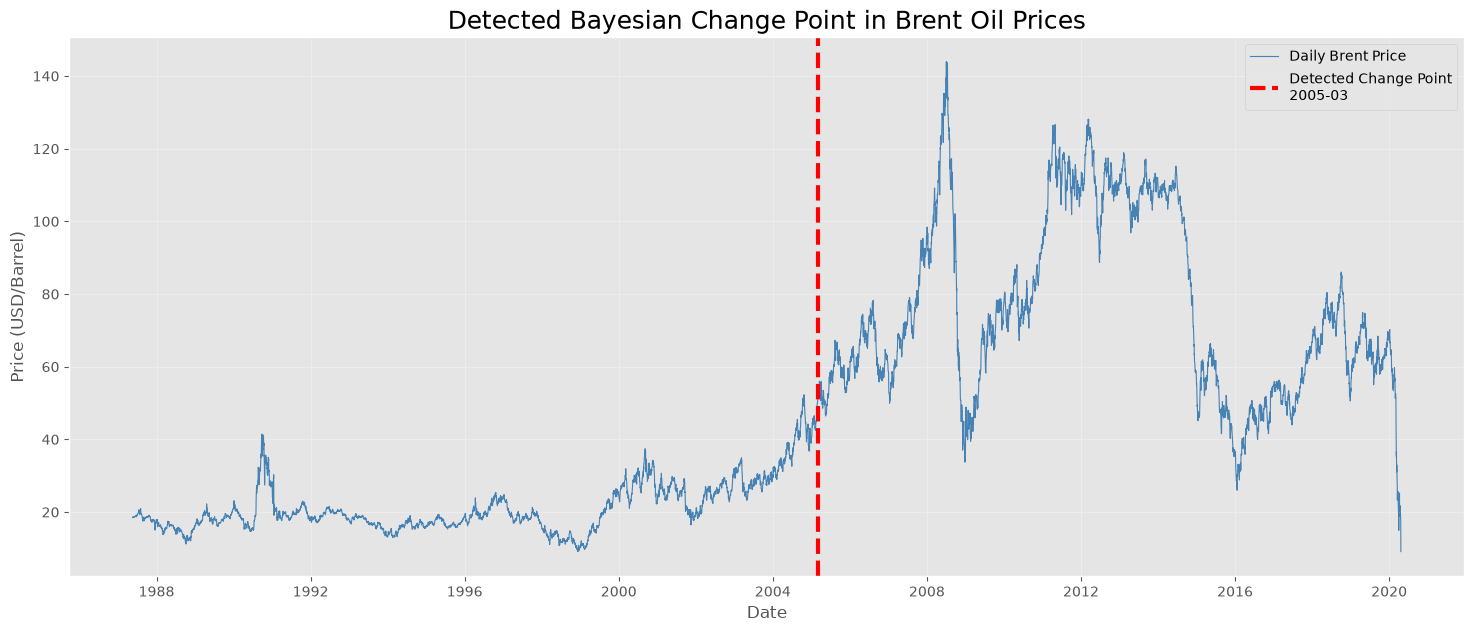

In [19]:
plt.figure(figsize=(18,7))

plt.plot(
    df["Date"],
    df["Price"],
    color="steelblue",
    linewidth=0.8,
    label="Daily Brent Price"
)

plt.axvline(
    change_date_mode,
    color="red",
    linestyle="--",
    linewidth=3,
    label=f"Detected Change Point\n{change_date_mode.strftime('%Y-%m')}"
)

plt.title("Detected Bayesian Change Point in Brent Oil Prices", fontsize=18)

plt.xlabel("Date")

plt.ylabel("Price (USD/Barrel)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [20]:
before = monthly_df[
    monthly_df["Date"] < change_date_mode
]["Price"]

after = monthly_df[
    monthly_df["Date"] >= change_date_mode
]["Price"]

comparison = pd.DataFrame({
    "Period":[
        "Before Change",
        "After Change"
    ],
    "Average Price":[
        before.mean(),
        after.mean()
    ]
})

comparison

,Period,Average Price
0,Before Change,21.387057
1,After Change,76.008724


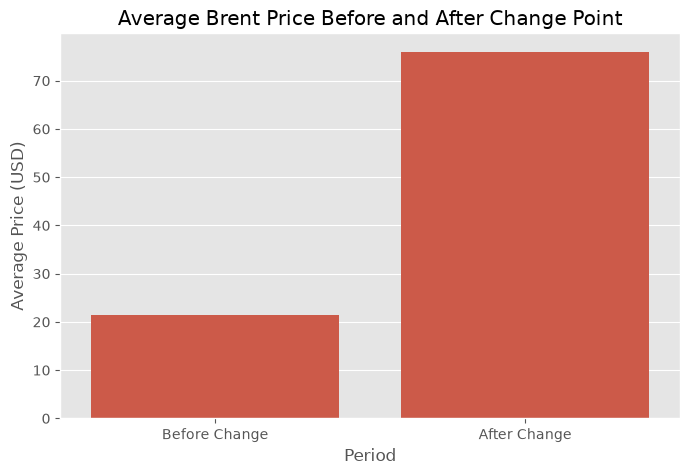

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Period",
    y="Average Price"
)

plt.title("Average Brent Price Before and After Change Point")

plt.ylabel("Average Price (USD)")

plt.show()

In [22]:
monthly_df.to_csv(
    "../data/processed/monthly_prices.csv",
    index=False
)

events_df.to_csv(
    "../data/processed/events.csv",
    index=False
)

summary_table.to_csv(
    "../data/processed/model_summary.csv",
    index=False
)

NameError: name 'events_df' is not defined

In [23]:
# ============================================================
# Load Geopolitical Events Dataset
# ============================================================

events_df = pd.read_csv("../data/external/oil_events.csv")

events_df["Date"] = pd.to_datetime(events_df["Date"])

events_df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/external/oil_events.csv'

In [25]:
import pandas as pd

events_df = pd.read_csv("../data/raw/oil_events.csv")
events_df["Date"] = pd.to_datetime(events_df["Date"])

events_df.head()

,Date,Event,Category,Expected_Impact
0,1990-08-02,Iraq invades Kuwait,Conflict,Price Increase
1,1991-01-17,Operation Desert Storm begins,Conflict,High Volatility
2,1997-07-02,Asian Financial Crisis,Economy,Price Decrease
3,1998-12-11,OPEC production cut,OPEC,Price Increase
4,2001-09-11,September 11 terrorist attacks,Political,High Volatility


# Event Association Analysis

This notebook compares detected Brent oil price change points with major geopolitical, economic, and OPEC-related events. The objective is to identify plausible temporal associations and quantify price movements around each event.

In [26]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (15, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [27]:
events_df = pd.read_csv("../data/raw/oil_events.csv")

events_df["Date"] = pd.to_datetime(
    events_df["Date"],
    errors="coerce"
)

events_df = (
    events_df.dropna(subset=["Date"])
             .sort_values("Date")
             .reset_index(drop=True)
)

print("Number of events:", len(events_df))
print("Date range:", events_df["Date"].min(), "to", events_df["Date"].max())

events_df.head()

Number of events: 20
Date range: 1990-08-02 00:00:00 to 2022-02-24 00:00:00


,Date,Event,Category,Expected_Impact
0,1990-08-02,Iraq invades Kuwait,Conflict,Price Increase
1,1991-01-17,Operation Desert Storm begins,Conflict,High Volatility
2,1997-07-02,Asian Financial Crisis,Economy,Price Decrease
3,1998-12-11,OPEC production cut,OPEC,Price Increase
4,2001-09-11,September 11 terrorist attacks,Political,High Volatility


In [28]:
prices_df = pd.read_csv("../data/processed/monthly_prices.csv")

prices_df["Date"] = pd.to_datetime(
    prices_df["Date"],
    errors="coerce"
)

prices_df = (
    prices_df.dropna(subset=["Date", "Price"])
             .sort_values("Date")
             .reset_index(drop=True)
)

prices_df.head()

,Date,Price
0,1987-05-01,18.580000
1,1987-06-01,18.860476
2,1987-07-01,19.856522
3,1987-08-01,18.979524
4,1987-09-01,18.313182


In [29]:
# ============================================================
# Calculate Event-Level Price Impacts
# ============================================================

def calculate_event_impact(
    event_date,
    price_data,
    months_before=3,
    months_after=3
):
    event_date = pd.Timestamp(event_date)

    before_start = event_date - pd.DateOffset(months=months_before)
    after_end = event_date + pd.DateOffset(months=months_after)

    before_period = price_data[
        (price_data["Date"] >= before_start) &
        (price_data["Date"] < event_date)
    ]["Price"]

    after_period = price_data[
        (price_data["Date"] >= event_date) &
        (price_data["Date"] <= after_end)
    ]["Price"]

    if len(before_period) == 0 or len(after_period) == 0:
        return pd.Series({
            "Average_Before": np.nan,
            "Average_After": np.nan,
            "Absolute_Change": np.nan,
            "Percentage_Change": np.nan
        })

    average_before = before_period.mean()
    average_after = after_period.mean()

    absolute_change = average_after - average_before
    percentage_change = (
        absolute_change / average_before
    ) * 100

    return pd.Series({
        "Average_Before": average_before,
        "Average_After": average_after,
        "Absolute_Change": absolute_change,
        "Percentage_Change": percentage_change
    })

In [30]:
event_impacts = events_df.apply(
    lambda row: calculate_event_impact(
        row["Date"],
        prices_df,
        months_before=3,
        months_after=3
    ),
    axis=1
)

event_analysis_df = pd.concat(
    [events_df, event_impacts],
    axis=1
)

event_analysis_df.head()

,Date,Event,Category,Expected_Impact,Average_Before,Average_After,Absolute_Change,Percentage_Change
0,1990-08-02,Iraq invades Kuwait,Conflict,Price Increase,19.813748,34.662960,14.849212,74.943985
1,1991-01-17,Operation Desert Storm begins,Conflict,High Volatility,28.302379,19.266167,-9.036212,-31.927394
2,1997-07-02,Asian Financial Crisis,Economy,Price Decrease,18.355786,18.973890,0.618104,3.367354
3,1998-12-11,OPEC production cut,OPEC,Price Increase,11.188535,11.299128,0.110592,0.988444
4,2001-09-11,September 11 terrorist attacks,Political,High Volatility,25.304379,19.346787,-5.957591,-23.543718


In [31]:
event_analysis_df["Observed_Direction"] = np.where(
    event_analysis_df["Percentage_Change"] > 0,
    "Increase",
    "Decrease"
)

event_analysis_df["Impact_Magnitude"] = pd.cut(
    event_analysis_df["Percentage_Change"].abs(),
    bins=[0, 5, 15, 30, np.inf],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ],
    include_lowest=True
)

event_analysis_df[
    [
        "Date",
        "Event",
        "Category",
        "Expected_Impact",
        "Average_Before",
        "Average_After",
        "Percentage_Change",
        "Observed_Direction",
        "Impact_Magnitude"
    ]
].round(2)

,Date,Event,Category,Expected_Impact,Average_Before,Average_After,Percentage_Change,Observed_Direction,Impact_Magnitude
0,1990-08-02,Iraq invades Kuwait,Conflict,Price Increase,19.81,34.66,74.94,Increase,Very High
1,1991-01-17,Operation Desert Storm begins,Conflict,High Volatility,28.30,19.27,-31.93,Decrease,Very High
2,1997-07-02,Asian Financial Crisis,Economy,Price Decrease,18.36,18.97,3.37,Increase,Low
3,1998-12-11,OPEC production cut,OPEC,Price Increase,11.19,11.30,0.99,Increase,Low
4,2001-09-11,September 11 terrorist attacks,Political,High Volatility,25.30,19.35,-23.54,Decrease,High
5,2003-03-20,Iraq War begins,Conflict,Price Increase,31.52,26.19,-16.91,Decrease,High
6,2005-08-29,Hurricane Katrina,Disaster,Price Increase,58.62,58.90,0.47,Increase,Low
7,2008-09-15,Global Financial Crisis,Economy,Price Decrease,114.40,54.66,-52.22,Decrease,Very High
8,2010-12-18,Arab Spring begins,Political,Price Increase,86.46,104.96,21.40,Increase,High
9,2011-02-15,Libyan Civil War,Conflict,Price Increase,97.23,117.63,20.98,Increase,High


In [32]:
largest_impacts = (
    event_analysis_df
    .dropna(subset=["Percentage_Change"])
    .assign(
        Absolute_Percentage_Change=lambda x:
        x["Percentage_Change"].abs()
    )
    .sort_values(
        "Absolute_Percentage_Change",
        ascending=False
    )
)

largest_impacts[
    [
        "Date",
        "Event",
        "Category",
        "Percentage_Change",
        "Observed_Direction",
        "Impact_Magnitude"
    ]
].head(10).round(2)

,Date,Event,Category,Percentage_Change,Observed_Direction,Impact_Magnitude
0,1990-08-02,Iraq invades Kuwait,Conflict,74.94,Increase,Very High
16,2020-03-11,COVID-19 declared pandemic,Health,-61.11,Decrease,Very High
15,2020-03-08,Saudi-Russia oil price war,OPEC,-61.11,Decrease,Very High
7,2008-09-15,Global Financial Crisis,Economy,-52.22,Decrease,Very High
10,2014-11-27,OPEC maintains production,OPEC,-36.28,Decrease,Very High
1,1991-01-17,Operation Desert Storm begins,Conflict,-31.93,Decrease,Very High
4,2001-09-11,September 11 terrorist attacks,Political,-23.54,Decrease,High
11,2015-07-14,Iran Nuclear Deal,Political,-21.71,Decrease,High
8,2010-12-18,Arab Spring begins,Political,21.40,Increase,High
9,2011-02-15,Libyan Civil War,Conflict,20.98,Increase,High


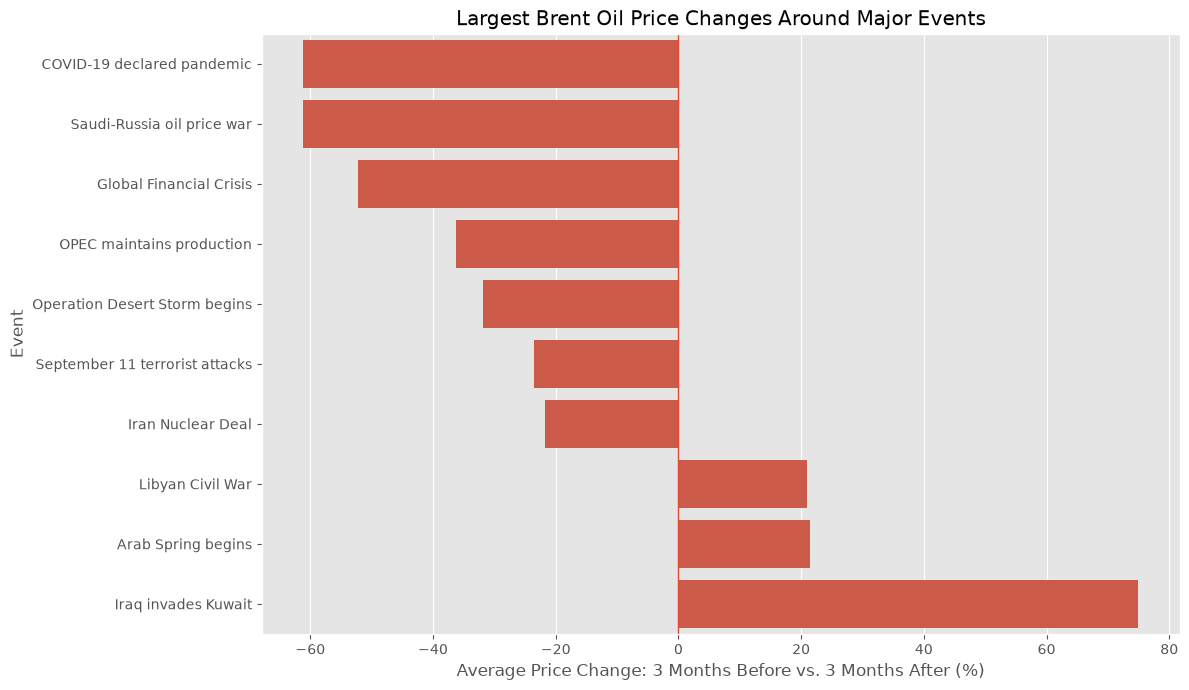

In [33]:
plot_df = largest_impacts.head(10).sort_values(
    "Percentage_Change"
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=plot_df,
    x="Percentage_Change",
    y="Event"
)

plt.axvline(0, linewidth=1)

plt.title(
    "Largest Brent Oil Price Changes Around Major Events"
)

plt.xlabel(
    "Average Price Change: 3 Months Before vs. 3 Months After (%)"
)

plt.ylabel("Event")

plt.tight_layout()
plt.show()

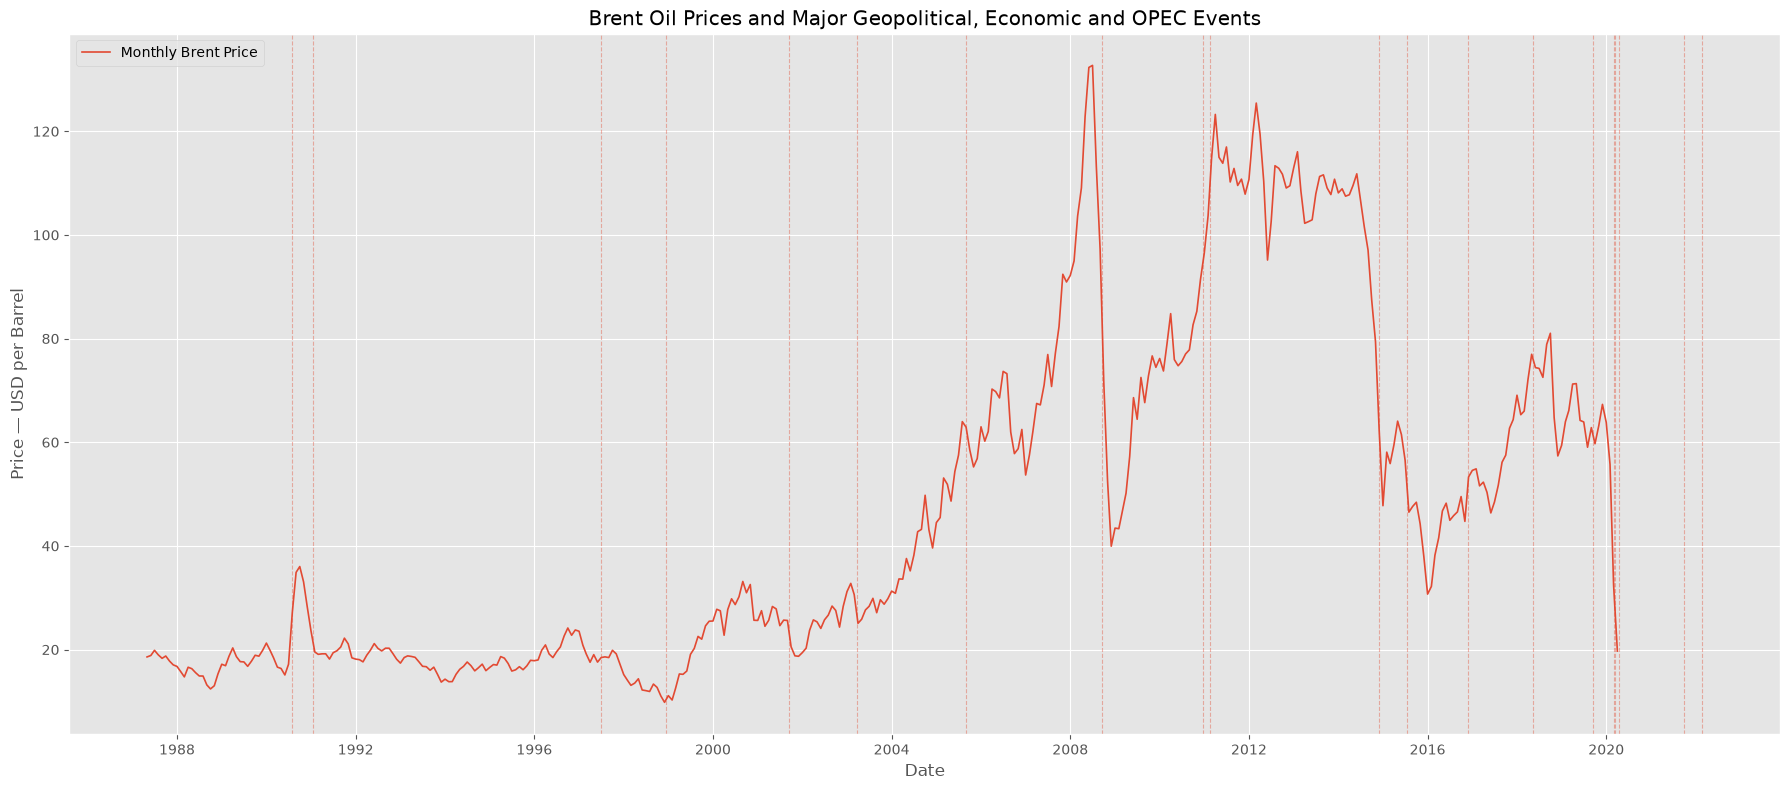

In [34]:
plt.figure(figsize=(18, 8))

plt.plot(
    prices_df["Date"],
    prices_df["Price"],
    linewidth=1.2,
    label="Monthly Brent Price"
)

for _, row in events_df.iterrows():
    plt.axvline(
        row["Date"],
        linestyle="--",
        linewidth=0.8,
        alpha=0.4
    )

plt.title(
    "Brent Oil Prices and Major Geopolitical, Economic and OPEC Events"
)

plt.xlabel("Date")
plt.ylabel("Price — USD per Barrel")
plt.legend()

plt.tight_layout()
plt.show()

In [35]:
event_analysis_df.to_csv(
    "../data/processed/event_analysis.csv",
    index=False
)

print("Event analysis saved successfully.")

Event analysis saved successfully.
